In [1]:
import pandas as pd
import numpy as np

import datetime
from collections import Counter

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

from tensorflow.keras.losses import Huber

In [1]:
df_train = pd.read_csv('train_data.csv')

In [ ]:
df_train.head()

In [ ]:
def impute_values(df):
    # Step 1: Encode categorical columns
    label_encoder1 = LabelEncoder()
    label_encoder2 = LabelEncoder()
    label_encoder3 = LabelEncoder()
    label_encoder4 = LabelEncoder()
    label_encoder5 = LabelEncoder()

    # Handle missing values for categorical columns before encoding
    df['Outlet_Size'] = df['Outlet_Size'].fillna('Missing')

    # Encode categorical columns
    df['Outlet_Size'] = label_encoder1.fit_transform(df['Outlet_Size'].astype(str))
    df['Item_Fat_Content'] = label_encoder2.fit_transform(df['Item_Fat_Content'].astype(str))
    df['Item_Type'] = label_encoder3.fit_transform(df['Item_Type'].astype(str))
    df['Outlet_Location_Type'] = label_encoder4.fit_transform(df['Outlet_Location_Type'].astype(str))
    df['Outlet_Type'] = label_encoder5.fit_transform(df['Outlet_Type'].astype(str))

    # Step 2: Apply KNN Imputer to the entire dataset (except categorical columns)
    df_impute = df.drop(columns=['Item_Identifier', 'Outlet_Identifier'])  # Dropping non-numeric columns

    # Initialize KNN Imputer
    knn_imputer = KNNImputer(n_neighbors=5)

    # Perform the imputation
    df_imputed = knn_imputer.fit_transform(df_impute)

    # Convert the imputed array back to DataFrame
    df_imputed = pd.DataFrame(df_imputed, columns=df_impute.columns)

    # Step 3: Impute only the numeric columns (Numeric_1 and Numeric_2)
    df_imputed_numeric = knn_imputer.fit_transform(df_imputed.drop(columns=['Outlet_Size']))

    # Step 4: Manually impute missing values in the categorical column using the most frequent category of neighbors
    for idx in df_imputed[df_imputed['Outlet_Size'].isna()].index:
        # Get the indices of the nearest neighbors
        neighbors = df_imputed_numeric[idx]

        # Find the corresponding indices for the neighbors
        neighbor_indices = [i for i in range(len(neighbors)) if i != idx]

        # Get the categories of the neighbors
        neighbor_categories = df_imputed.loc[neighbor_indices, 'Outlet_Size'].values

        # Count the frequency of each category
        counter = Counter(neighbor_categories)

        # Find the most common category (most frequent)
        imputed_category = counter.most_common(1)[0][0]

        # Assign the most frequent category to the missing value
        df_imputed.loc[idx, 'Outlet_Size'] = imputed_category


    # Step 5: Reassign the imputed values back to the original DataFrame
    df['Item_Weight'] = df_imputed['Item_Weight']
    df['Outlet_Size'] = df_imputed['Outlet_Size'].astype(int)

    # Step 6: Convert encoded categorical values back to their original labels
    # Ensure that inverse_transform is called after encoding
    df['Outlet_Size'] = label_encoder1.inverse_transform(df['Outlet_Size'])
    df['Item_Fat_Content'] = label_encoder2.inverse_transform(df['Item_Fat_Content'])
    df['Item_Type'] = label_encoder3.inverse_transform(df['Item_Type'])
    df['Outlet_Location_Type'] = label_encoder4.inverse_transform(df['Outlet_Location_Type'])
    df['Outlet_Type'] = label_encoder5.inverse_transform(df['Outlet_Type'])

    return df

# Example usage
# df_tmp = impute_values(df_train)

In [ ]:
df_train = impute_values(df_train)

In [ ]:
df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Missing,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# Calculate null rates for each column
null_rates = df_train.isnull().sum() / len(df_train) * 100
null_rates

,0
Item_Identifier,0.0
Item_Weight,0.0
Item_Fat_Content,0.0
Item_Visibility,0.0
Item_Type,0.0
Item_MRP,0.0
Outlet_Identifier,0.0
Outlet_Establishment_Year,0.0
Outlet_Size,0.0
Outlet_Location_Type,0.0


In [ ]:
from scipy.stats import mstats
#df_train['Item_Outlet_Sales'] = mstats.winsorize(df_train['Item_Outlet_Sales'], limits=[0.0, 0.1])

In [ ]:
fat_content_map = {'Low Fat': 'Low Fat', 'low fat': 'Low Fat',
                   'Regular': 'Regular', 'LF': 'Low Fat', 'reg': 'Regular'}

def process_fat_content(x):
  return fat_content_map[x]

df_train['Item_Fat_Content'] = df_train['Item_Fat_Content'].apply(process_fat_content)

In [ ]:
df_train['Outlet_Type'].unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

In [ ]:
# categorical maps
# One hot encode Item type, outlet_type

fat_map = {'Low Fat': 0, 'Regular': 1}
outlet_size_map = {'Medium': 1, 'High': 2, 'Small': 0, 'Missing': 3}
outlet_location_type = {'Tier 1': 2, 'Tier 3': 0, 'Tier 2': 1}

In [ ]:
df_train['Item_Fat_Content'] = df_train['Item_Fat_Content'].apply(lambda x: fat_map[x])
df_train['Outlet_Size'] = df_train['Outlet_Size'].apply(lambda x: outlet_size_map[x])
df_train['Outlet_Location_Type'] = df_train['Outlet_Location_Type'].apply(lambda x: outlet_location_type[x])

In [ ]:
curr_year = datetime.datetime.now().year
df_train['Outlet_Age'] = curr_year - df_train['Outlet_Establishment_Year']

In [ ]:
drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year']
df_train = df_train.drop(columns=drop_cols, axis=1)

In [ ]:
def encode_categorical_cols(df):
    # Identify categorical columns
    categorical_cols = ['Item_Type', 'Outlet_Type']

    # Perform One-Hot Encoding on categorical columns
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

In [ ]:
def encode_train_data(df_train):
    """
    Encodes the categorical columns in the training data using Label Encoding.

    Parameters:
    - df_train: pandas DataFrame containing the training data.

    Returns:
    - df_train_encoded: DataFrame with encoded categorical columns in the training data.
    - label_mappings: Dictionary with mappings of categorical values to encoded labels.
    """
    # Identify categorical columns in the training data
    categorical_cols = df_train.select_dtypes(include=['object']).columns

    # Initialize LabelEncoder
    label_encoder = LabelEncoder()

    # Dictionary to store the mappings
    label_mappings = {}

    # Encode categorical columns in the training data
    for col in categorical_cols:
        # Fit the encoder to the training data column
        label_encoder.fit(df_train[col])

        # Store the mapping of the column's categories to integer labels
        label_mappings[col] = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

        # Transform the column to integer labels
        df_train[col] = label_encoder.transform(df_train[col])

    return df_train, label_mappings

def encode_test_data(df_test, label_mappings):
    """
    Encodes the categorical columns in the test data using pre-fitted label mappings from training data.

    Parameters:
    - df_test: pandas DataFrame containing the test data.
    - label_mappings: Dictionary with mappings of categorical values to encoded labels from training data.

    Returns:
    - df_test_encoded: DataFrame with encoded categorical columns in the test data.
    """
    # Iterate through the columns in the label_mappings
    for col, mapping in label_mappings.items():
        # Map the test data using the pre-defined mapping
        df_test[col] = df_test[col].map(mapping).fillna(-1).astype(int)  # Handle unseen categories

    return df_test

In [ ]:
df_train = encode_categorical_cols(df_train)
#df_train, label_mappings = encode_train_data(df_train)

In [ ]:
df_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Outlet_Age,Item_Type_Breads,Item_Type_Breakfast,...,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0,0.016047,249.8092,1,2,3735.1380,26,False,False,...,False,False,False,False,False,False,False,True,False,False
1,5.92,1,0.019278,48.2692,1,0,443.4228,16,False,False,...,False,False,False,False,False,True,False,False,True,False
2,17.50,0,0.016760,141.6180,1,2,2097.2700,26,False,False,...,False,True,False,False,False,False,False,True,False,False
3,19.20,1,0.000000,182.0950,3,0,732.3800,27,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8.93,0,0.000000,53.8614,2,0,994.7052,38,False,False,...,True,False,False,False,False,False,False,True,False,False


In [ ]:
def scale_values(df, cols_to_scale, scaler=None):
    """
    Scales the specified columns in a DataFrame using Standard Scaling (Z-score scaling).

    Parameters:
    - df: pandas DataFrame containing the data.
    - cols_to_scale: List of column names to scale.
    - scaler: Pre-fitted StandardScaler object. If None, the scaler will be fitted on the data.

    Returns:
    - df_scaled: DataFrame with scaled values.
    - scaler: Fitted StandardScaler object.
    """

    if scaler is None:
        scaler = StandardScaler()
        # Fit the scaler on the training data and transform the specified columns
        df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    else:
        # Use the pre-fitted scaler to transform the test data
        df[cols_to_scale] = scaler.transform(df[cols_to_scale])

    return df, scaler


In [ ]:
cols_to_scale = ['Item_Weight', 'Item_MRP',	'Outlet_Age']
df_train, scaler = scale_values(df_train, cols_to_scale)

In [ ]:
df_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Outlet_Age,Item_Type_Breads,Item_Type_Breakfast,...,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,-0.822517,0,0.016047,1.747454,1,2,3735.1380,-0.139541,False,False,...,False,False,False,False,False,False,False,True,False,False
1,-1.606135,1,0.019278,-1.489023,1,0,443.4228,-1.334103,False,False,...,False,False,False,False,False,True,False,False,True,False
2,1.078569,0,0.016760,0.010040,1,2,2097.2700,-0.139541,False,False,...,False,True,False,False,False,False,False,True,False,False
3,1.472696,1,0.000000,0.660050,3,0,732.3800,-0.020085,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.908297,0,0.000000,-1.399220,2,0,994.7052,1.293934,False,False,...,True,False,False,False,False,False,False,True,False,False


In [ ]:
def log_transform(df, cols_to_transform):
    """
    Applies log transformation to the specified columns in the DataFrame.

    Parameters:
    - df: pandas DataFrame containing the data.
    - cols_to_transform: List of column names to apply log transformation.

    Returns:
    - df_transformed: DataFrame with log-transformed values.
    """

    for col in cols_to_transform:
        # Apply log transformation
        # Adding 1 to avoid log(0) issues, as log(0) is undefined
        df[col] = np.log(df[col] + 1)

    return df

In [ ]:
def inverse_log_transform(log_tr):
    return np.exp(log_tr) - 1

In [ ]:
np.log(0+1)

np.float64(0.0)

In [ ]:
cols_to_transform = ['Item_Visibility', 'Item_Outlet_Sales']
#cols_to_transform = ['Item_Visibility']
df_train = log_transform(df_train, cols_to_transform)

In [ ]:
df_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Outlet_Age,Item_Type_Breads,Item_Type_Breakfast,...,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,-0.822517,0,0.015920,1.747454,1,2,8.225808,-0.139541,False,False,...,False,False,False,False,False,False,False,True,False,False
1,-1.606135,1,0.019095,-1.489023,1,0,6.096776,-1.334103,False,False,...,False,False,False,False,False,True,False,False,True,False
2,1.078569,0,0.016621,0.010040,1,2,7.648868,-0.139541,False,False,...,False,True,False,False,False,False,False,True,False,False
3,1.472696,1,0.000000,0.660050,3,0,6.597664,-0.020085,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.908297,0,0.000000,-1.399220,2,0,6.903451,1.293934,False,False,...,True,False,False,False,False,False,False,True,False,False


In [ ]:
def plot_predictions(prediction_data):
  keys = list(prediction_data)

  original_y = prediction_data[keys[0]]
  predicted_y = prediction_data[keys[1]]

  # Plotting
  plt.figure(figsize=(20,6))

  # Plot the original values
  plt.plot(original_y, label='Original Values',
           color='black', linestyle='-', marker='o')

  # Plot the predicted values
  plt.plot(predicted_y, label='Predicted Values', linestyle='--', marker='x')

  # Adding labels and title
  plt.xlabel('Original Values')
  plt.ylabel('Predicted Values')
  plt.title('Comparison of Original and Model Predictions')
  plt.legend()

  # Show the plot
  plt.grid(True)
  plt.show()

In [ ]:
def train_regression_model(df, target_column='Item_Outlet_Sales'):
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Split the data into training and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize the regression model (you can replace this with any other regressor)
    model = LinearRegression()

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    prediction_data = {}
    prediction_data['Original_y'] = inverse_log_transform(y_test.to_numpy())
    prediction_data['Regg_y'] = inverse_log_transform(y_pred)

    #prediction_data['Original_y'] = y_test.to_numpy()
    #prediction_data['Regg_y'] = y_pred

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Return the model and evaluation metrics
    return model, mse, r2, prediction_data

In [ ]:
model, mse, r2, prediction_data = train_regression_model(df_train)

In [ ]:
mse, r2

(0.28423340950061254, 0.7296475899835233)

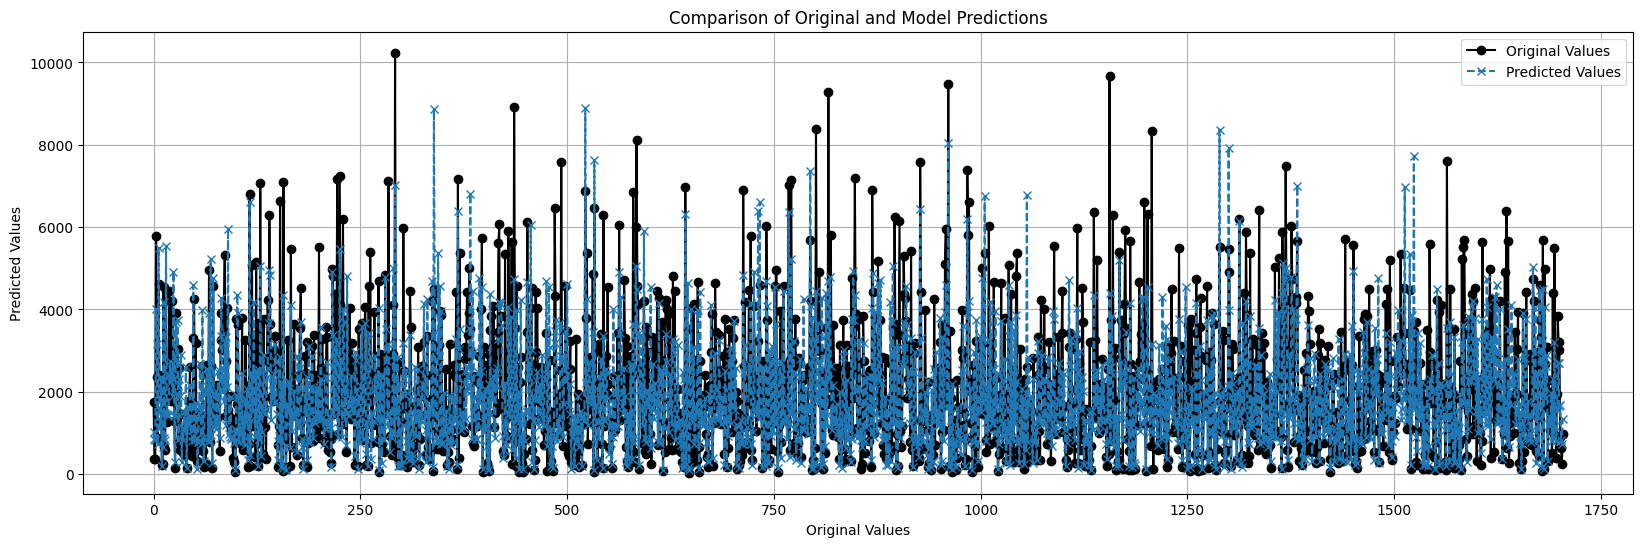

In [ ]:
plot_predictions(prediction_data)

In [ ]:
def train_tree_based_model(df, target_column='Item_Outlet_Sales', model_type='DecisionTree'):
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Split the data into training and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize the tree-based model based on the model_type parameter
    if model_type == 'DecisionTree':
        model = DecisionTreeRegressor(random_state=42)
    elif model_type == 'RandomForest':
        model = RandomForestRegressor(random_state=42)
    elif model_type == 'GradientBoosting':
        model = GradientBoostingRegressor(random_state=42)
    else:
        raise ValueError("Unsupported model type. Choose from 'DecisionTree', 'RandomForest', or 'GradientBoosting'.")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    prediction_data = {}
    prediction_data['Original_y'] = inverse_log_transform(y_test.to_numpy())

    if model_type == 'DecisionTree':
        prediction_data['DecisionTree_y'] = inverse_log_transform(y_pred)
    elif model_type == 'RandomForest':
        prediction_data['RandomForest_y'] = inverse_log_transform(y_pred)
    elif model_type == 'GradientBoosting':
        prediction_data['GradientBoosting_y'] = inverse_log_transform(y_pred)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(mse, r2)

    # Return the model and evaluation metrics
    return model, mse, r2, prediction_data

# Example usage
# df = pd.read_csv('your_data.csv')  # Load your dataset
# model, mse, r2 = train_tree_based_model(df, model_type='RandomForest')
# print(f'Mean Squared Error: {mse}')
# print(f'R-squared: {r2}')


In [ ]:
model, mse, r2, prediction_data = train_tree_based_model(df_train, model_type='DecisionTree')

0.5252824515295822 0.5003705688226645


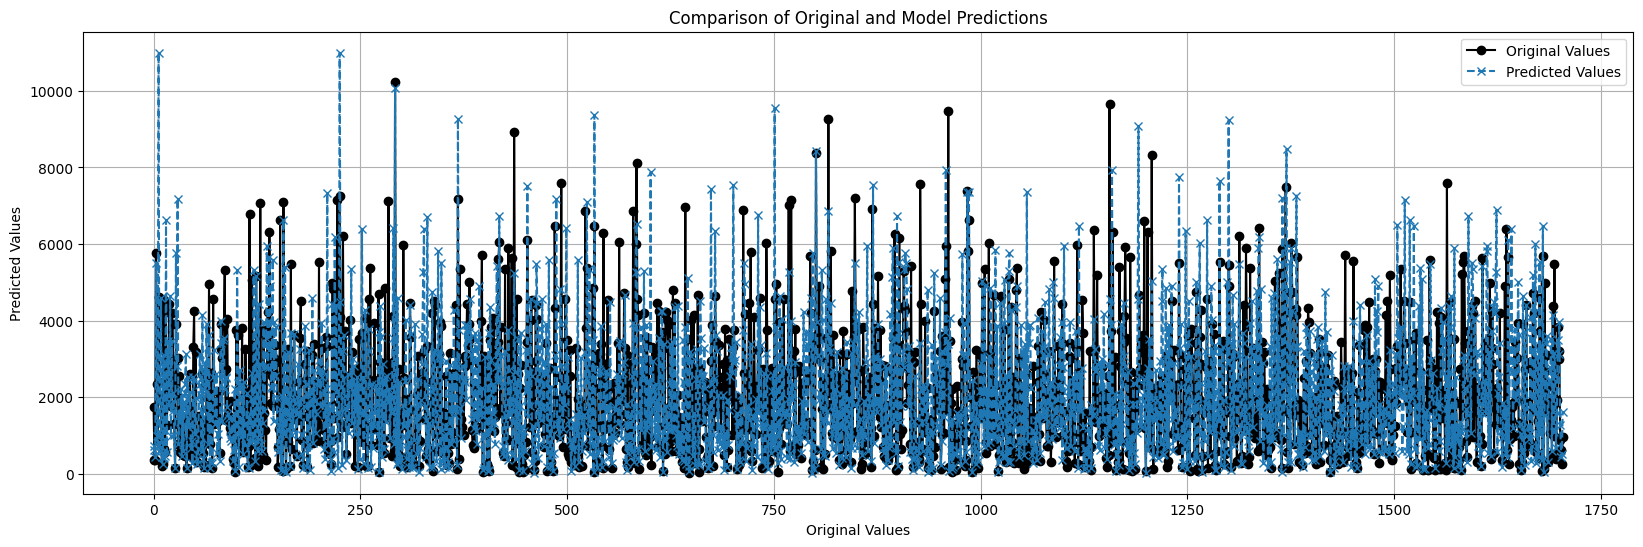

In [ ]:
plot_predictions(prediction_data)

In [ ]:
model, mse, r2, prediction_data = train_tree_based_model(df_train, model_type='RandomForest')

0.2985922939880371 0.7159899449053324


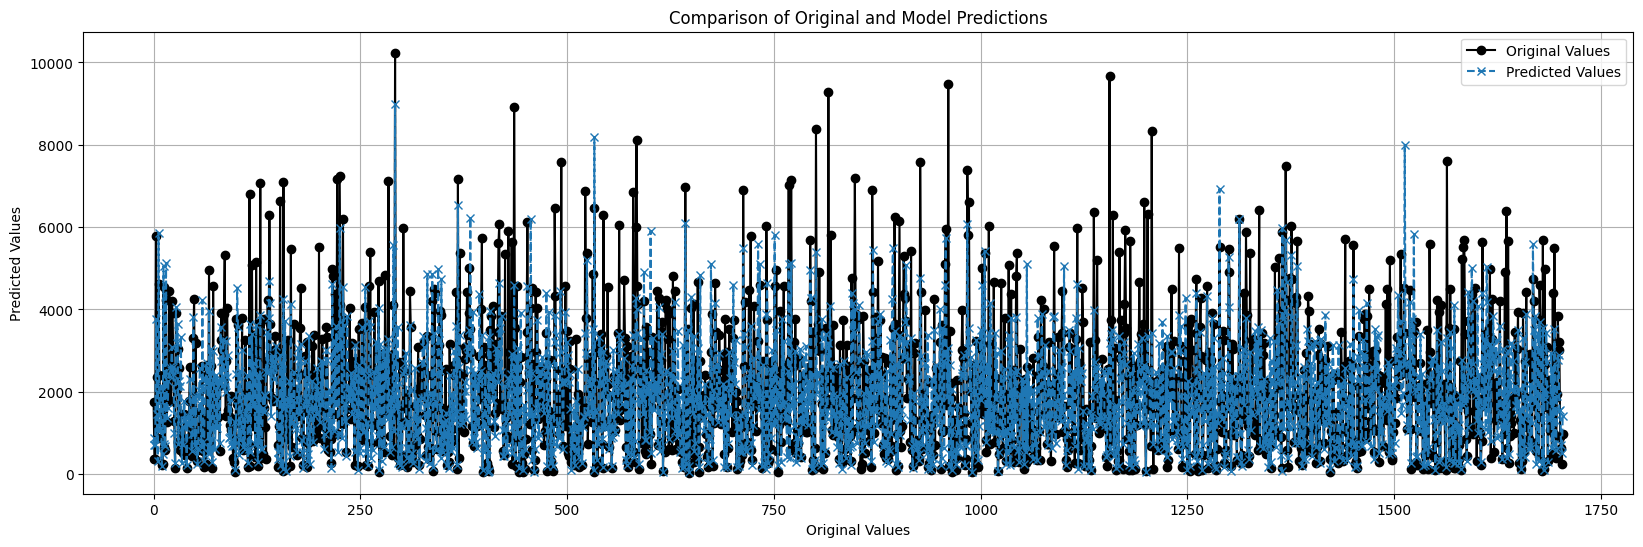

In [ ]:
plot_predictions(prediction_data)

In [ ]:
model, mse, r2, prediction_data = train_tree_based_model(df_train, model_type='GradientBoosting')

0.27191699335877845 0.7413625139699784


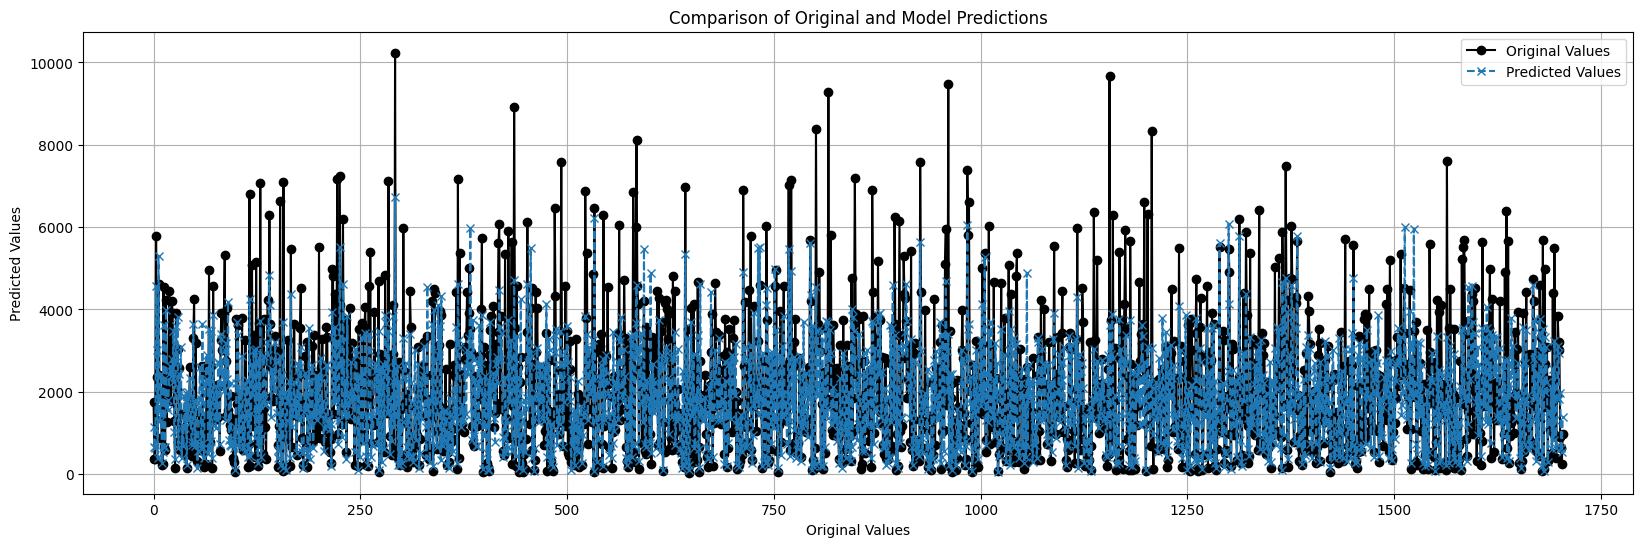

In [ ]:
plot_predictions(prediction_data)

In [ ]:
def train_boosted_model(df, target_column='Item_Outlet_Sales'):
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Split the data into training and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize the Gradient Boosting Regressor
    model = GradientBoostingRegressor(random_state=42)

    # Define the hyperparameters to tune
    param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        #'max_depth': [3, 4, 5],
        'subsample': [0.8, 0.9, 1.0],
        #'min_samples_split': [2, 5, 10],
        #'min_samples_leaf': [1, 2, 4],
    }

    # Use GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                               scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)

    # Train the model using GridSearchCV to find the best hyperparameters
    grid_search.fit(X_train, y_train)

    # Get the best model from the grid search
    best_model = grid_search.best_estimator_

    # Make predictions on the test set
    y_pred = best_model.predict(X_test)

    prediction_data = {}
    prediction_data['Original_y'] = inverse_log_transform(y_test.to_numpy())
    prediction_data['GradientBoostingRegressorBest_y'] = inverse_log_transform(y_pred)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(mse, r2)

    # Return the best model, evaluation metrics, and best hyperparameters
    return best_model, mse, r2, grid_search.best_params_, prediction_data


In [ ]:
best_model, mse, r2, best_params, prediction_data = train_boosted_model(df_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
0.2702756824059378 0.7429236688407819


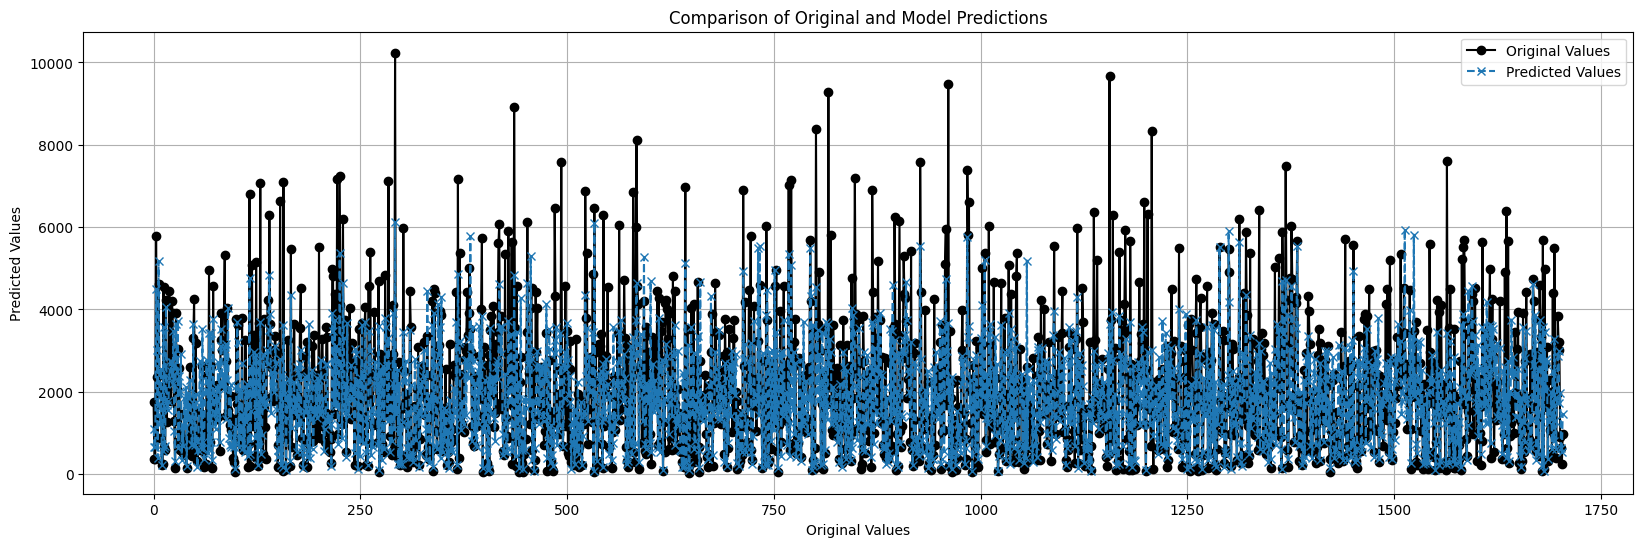

In [ ]:
plot_predictions(prediction_data)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def train_xgb_model_with_tuning(df, target_column='Item_Outlet_Sales',
                                test_size=0.2, random_state=42):
    """
    Trains an XGBoost Regressor with hyperparameter tuning.

    Returns:
    - best_model: Trained XGBoost model with best hyperparameters
    - X_test, y_test, y_pred: Test data and predictions
    - metrics: Evaluation results
    """

    # Split into X and y
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=test_size,
                                                        random_state=random_state)

    # Initial model
    model = XGBRegressor(random_state=random_state, n_jobs=-1)

    # Hyperparameter grid
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2, 0.5],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [1, 1.5, 2]
    }

    # Randomized search
    random_search = RandomizedSearchCV(
        model, param_distributions=param_dist,
        n_iter=25,  # number of different combinations to try
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=1,
        random_state=random_state,
        n_jobs=-1
    )

    # Fit search
    random_search.fit(X_train, y_train)

    # Best model
    best_model = random_search.best_estimator_

    # Predict
    y_pred = best_model.predict(X_test)

    prediction_data = {}
    prediction_data['Original_y'] = inverse_log_transform(y_test.to_numpy())
    prediction_data['XgBoostBest_y'] = inverse_log_transform(y_pred)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics = {'mse': mse, 'r2_score': r2}

    return best_model, X_test, y_test, y_pred, metrics, random_search, prediction_data

In [ ]:
best_model, X_test, y_test, y_pred, metrics, random_search, prediction_data = train_xgb_model_with_tuning(df_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [ ]:
metrics

{'mse': 0.26718584604025947, 'r2_score': 0.7458626080368649}

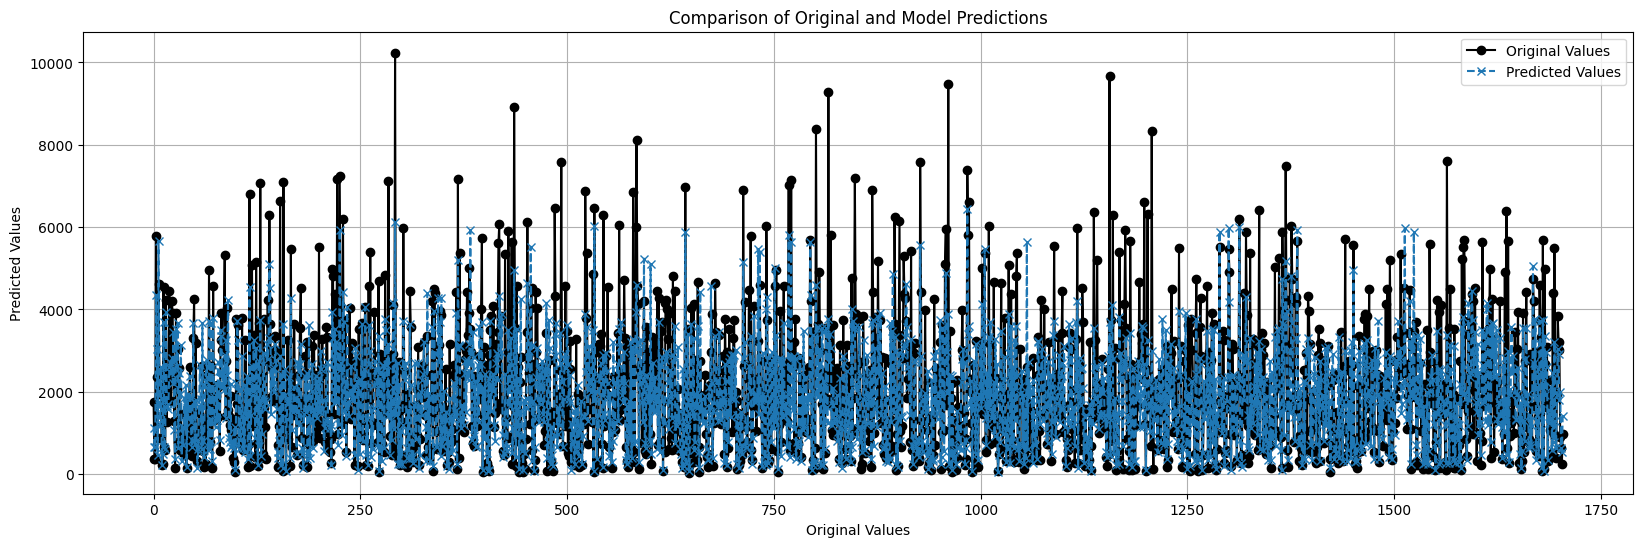

In [ ]:
plot_predictions(prediction_data)

In [ ]:
from xgboost import XGBRFRegressor

xg_final = XGBRFRegressor()

target_column='Item_Outlet_Sales'

# Split into X and y
X = df_train.drop(columns=[target_column])
y = df_train[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                 random_state=42)
xg_final.fit(X_train,y_train)
y_pred = xg_final.predict(X_test)

prediction_data = {}
prediction_data['Original_y'] = inverse_log_transform(y_test.to_numpy())
prediction_data['XGBRFRegressor_y'] = inverse_log_transform(y_pred)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = {'mse': mse, 'r2_score': r2}

In [ ]:
metrics

{'mse': 0.2669266284005804, 'r2_score': 0.7461091663627463}

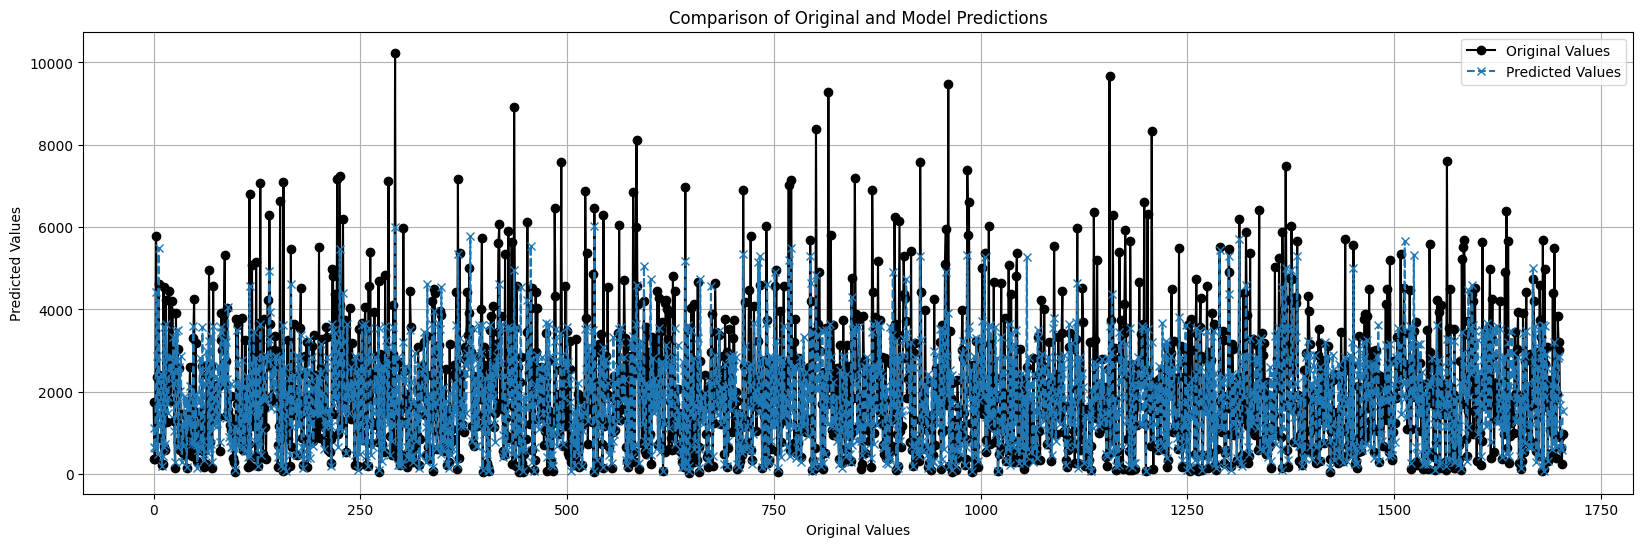

In [ ]:
plot_predictions(prediction_data)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def train_nn_regression_model(df, target_column='Item_Outlet_Sales'):
    """
    Trains a more complex neural network model for regression with additional layers, dropout, and batch normalization.

    Parameters:
    - df: pandas DataFrame containing the data.
    - target_column: The name of the column in `df` to predict (default is 'Item_Outlet_Sales').

    Returns:
    - model: Trained neural network model.
    - history: History object containing training details.
    - test_loss: The loss on the test data.
    - test_mae: Mean absolute error on the test data.
    """

    # Split the data into features (X) and target (y)
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Split the data into training and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build the Neural Network Model
    model = Sequential()

    # Input layer with the number of features
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # First hidden layer
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Second hidden layer
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Third hidden layer
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Output layer for regression (single neuron with no activation function)
    model.add(Dense(1))

    # Compile the model with an adaptive learning rate
    model.compile(optimizer=Adam(learning_rate=0.001), loss=Huber(), metrics=['mae'])

    # Train the model with additional callbacks (like early stopping)
    history = model.fit(X_train, y_train, epochs=200, batch_size=64, validation_split=0.2, verbose=1,
                        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)])

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model on the test data
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Return the trained model, training history, and evaluation metrics
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

    return model, history, test_loss, test_mae, X_test, y_test

In [ ]:
# Assuming `df` is the DataFrame containing the data with the target column `Item_Outlet_Sales`
model, history, test_loss, test_mae, X_test, y_test = train_nn_regression_model(df_train)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 6.6057 - mae: 7.1054 - val_loss: 5.7702 - val_mae: 6.2702
Epoch 2/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.5669 - mae: 6.0660 - val_loss: 3.7231 - val_mae: 4.2231
Epoch 3/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.8086 - mae: 4.2999 - val_loss: 1.4083 - val_mae: 1.8847
Epoch 4/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7801 - mae: 2.2352 - val_loss: 0.4486 - val_mae: 0.8445
Epoch 5/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0437 - mae: 1.4721 - val_loss: 0.2491 - val_mae: 0.5895
Epoch 6/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9280 - mae: 1.3507 - val_loss: 0.2075 - val_mae: 0.5231
Epoch 7/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8314 - mae: 1.2443 - val_loss: 0.1899 - val_mae: 0.5005
Epoch 8/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7476 - mae: 1.1534 - val_loss: 0.1793 - val_mae: 0.4869
Epoch 9/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.68

In [ ]:
y_pred = model.predict(X_test)

prediction_data = {}

prediction_data['Original_y'] = inverse_log_transform(y_test.to_numpy())
prediction_data['NeuralNetwork_y'] = inverse_log_transform(y_pred.flatten())

#prediction_data['Original_y'] = y_test.to_numpy()
#prediction_data['NeuralNetwork_y'] = y_pred.flatten()

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
y_test, y_pred = prediction_data['Original_y'], prediction_data['NeuralNetwork_y']

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = {'mse': mse, 'r2_score': r2}

metrics

{'mse': 1247628.0398282614, 'r2_score': 0.5409706474871945}

Test Loss: 0.13191653788089752
Test MAE: 0.41235873103141785


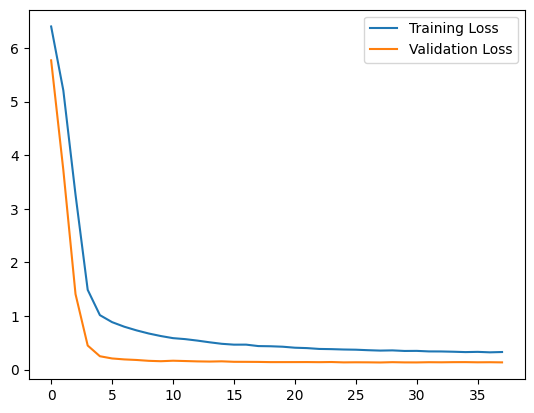

In [ ]:
# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

# You can also plot the training history to visualize the performance
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

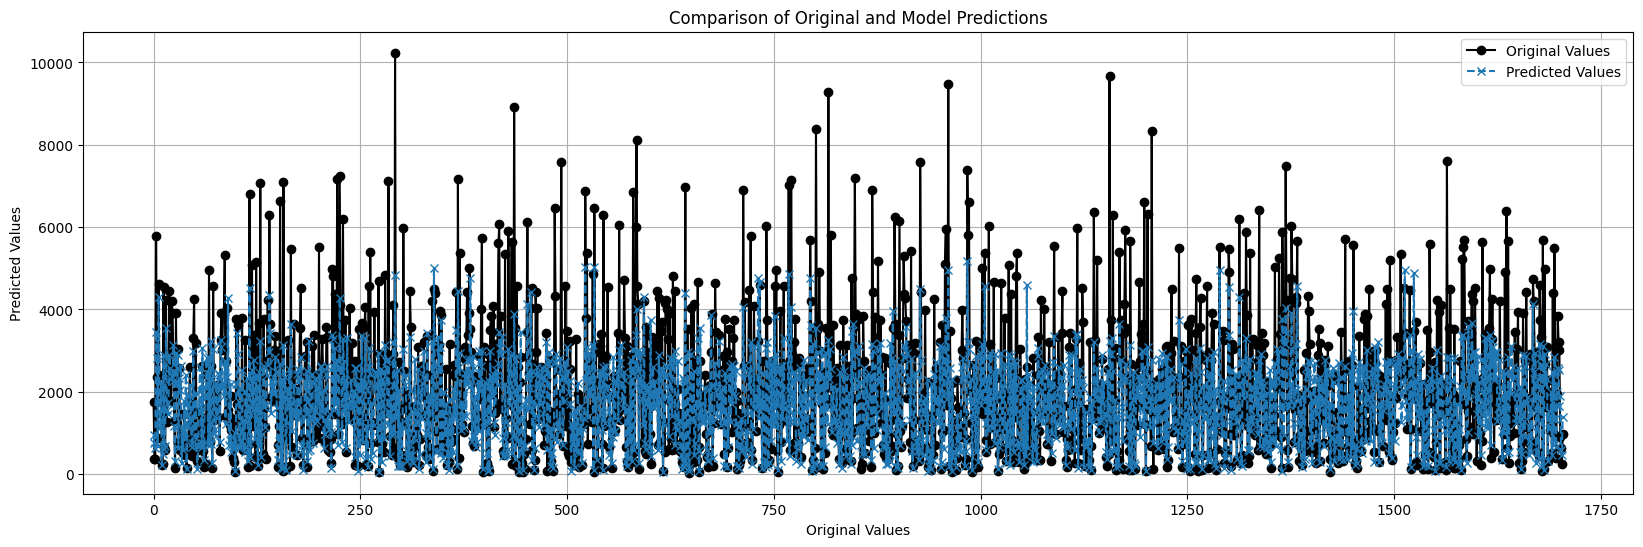

In [ ]:
plot_predictions(prediction_data)

In [ ]:
def pre_process_data(df, scaler, impute=False):

  if impute:
    df = impute_values(df)

  df['Item_Fat_Content'] = df['Item_Fat_Content'].apply(process_fat_content)

  df['Item_Fat_Content'] = df['Item_Fat_Content'].apply(lambda x: fat_map[x])
  df['Outlet_Size'] = df['Outlet_Size'].apply(lambda x: outlet_size_map[x])
  df['Outlet_Location_Type'] = df['Outlet_Location_Type'].apply(lambda x: outlet_location_type[x])

  curr_year = datetime.datetime.now().year
  df['Outlet_Age'] = curr_year - df['Outlet_Establishment_Year']

  drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year']
  df = df.drop(columns=drop_cols, axis=1)

  df = encode_categorical_cols(df)

  cols_to_scale = ['Item_Weight', 'Item_MRP',	'Outlet_Age']
  df, _ = scale_values(df, cols_to_scale, scaler=scaler)

  cols_to_transform = ['Item_Visibility']
  df = log_transform(df, cols_to_transform)

  return df

In [ ]:
df_test = pd.read_csv('test_data.csv')

In [ ]:
df_test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [ ]:
df_test.shape

(5681, 11)

In [ ]:
df_test_pr = pre_process_data(df_test, scaler, impute=True)

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
df_test_pr.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Age,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,1.866802,0,0.007536,-0.532035,1,2,-0.139541,False,False,False,...,False,False,False,False,True,False,False,True,False,False
1,-1.079321,1,0.037708,-0.861920,1,1,-1.095190,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.411488,0,0.094924,1.618094,1,0,-0.020085,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,-1.312408,0,0.015271,0.225484,2,1,-1.095190,False,False,False,...,False,False,False,False,True,False,False,True,False,False
4,-0.047829,1,0.112077,1.497272,1,0,1.532846,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
y_pred = model.predict(df_test_pr)

178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
#df_test['Predictions'] = inverse_log_transform(y_pred)
df_test['Predictions'] = y_pred

In [ ]:
df_test = df_test[['Item_Identifier', 'Outlet_Identifier', 'Predictions']]

In [ ]:
df_test = df_test.rename(columns={'Predictions': 'Item_Outlet_Sales'})

In [ ]:
df_test.head()

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,2010.230469
1,FDW14,OUT017,1254.000488
2,NCN55,OUT010,654.375244
3,FDQ58,OUT017,2060.419189
4,FDY38,OUT027,5230.689941


In [ ]:
df_test.to_csv('Result.csv', index=False)